# Fed-Vis: 3D Medical Image Segmentation Demo

This notebook demonstrates the Fed-Vis system for privacy-preserving 3D medical image segmentation using the Attention U-Net architecture.

## Contents
1. **Data Visualization** - Loading and visualizing 3D medical volumes
2. **Model Architecture** - Exploring the Attention U-Net structure
3. **Inference Demo** - Running predictions with attention maps
4. **Performance Metrics** - Initial evaluation results

## 1. Setup and Imports

In [1]:
# Standard imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# PyTorch
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Fed-Vis imports
from fedvis.models import AttentionUNet3D, CombinedLoss, DiceLoss
from fedvis.models.losses import dice_coefficient
from fedvis.models.blocks import AttentionGate, ConvBlock3D

print("\n✓ All imports successful!")

PyTorch version: 2.9.0+cpu
CUDA available: False

✓ All imports successful!


## 2. Data Visualization

We'll create synthetic 3D volume data to demonstrate the visualization capabilities.

In [2]:
def create_synthetic_volume(size=(64, 128, 128), tumor_radius=20):
    """
    Create a synthetic brain MRI volume with a spherical "tumor".
    
    Args:
        size: Volume dimensions (D, H, W)
        tumor_radius: Radius of synthetic tumor in voxels
    
    Returns:
        volume: Synthetic volume data
        mask: Ground truth segmentation mask
    """
    D, H, W = size
    
    # Create brain-like background with noise
    volume = np.random.randn(D, H, W) * 0.1 + 0.5
    
    # Add brain structure (ellipsoid)
    z, y, x = np.ogrid[:D, :H, :W]
    brain_center = (D//2, H//2, W//2)
    brain_radii = (D//3, H//2.5, W//2.5)
    
    brain_mask = (
        ((z - brain_center[0]) / brain_radii[0])**2 +
        ((y - brain_center[1]) / brain_radii[1])**2 +
        ((x - brain_center[2]) / brain_radii[2])**2
    ) <= 1
    
    volume[brain_mask] += 0.3  # Brighter brain region
    
    # Add tumor (sphere with higher intensity)
    tumor_center = (D//2, H//3, W//2)
    tumor = (
        (z - tumor_center[0])**2 +
        (y - tumor_center[1])**2 +
        (x - tumor_center[2])**2
    ) <= tumor_radius**2
    
    volume[tumor] = 0.9 + np.random.randn(tumor.sum()) * 0.05
    
    # Create ground truth mask
    mask = tumor.astype(np.float32)
    
    # Normalize volume
    volume = (volume - volume.min()) / (volume.max() - volume.min())
    
    return volume.astype(np.float32), mask

In [3]:
# Create synthetic data
volume, ground_truth = create_synthetic_volume(size=(64, 128, 128))

print(f"Volume shape: {volume.shape}")
print(f"Volume range: [{volume.min():.3f}, {volume.max():.3f}]")
print(f"Mask shape: {ground_truth.shape}")
print(f"Tumor voxels: {ground_truth.sum():.0f} ({100*ground_truth.mean():.2f}%)")

Volume shape: (64, 128, 128)
Volume range: [0.000, 1.000]
Mask shape: (64, 128, 128)
Tumor voxels: 33401 (3.19%)


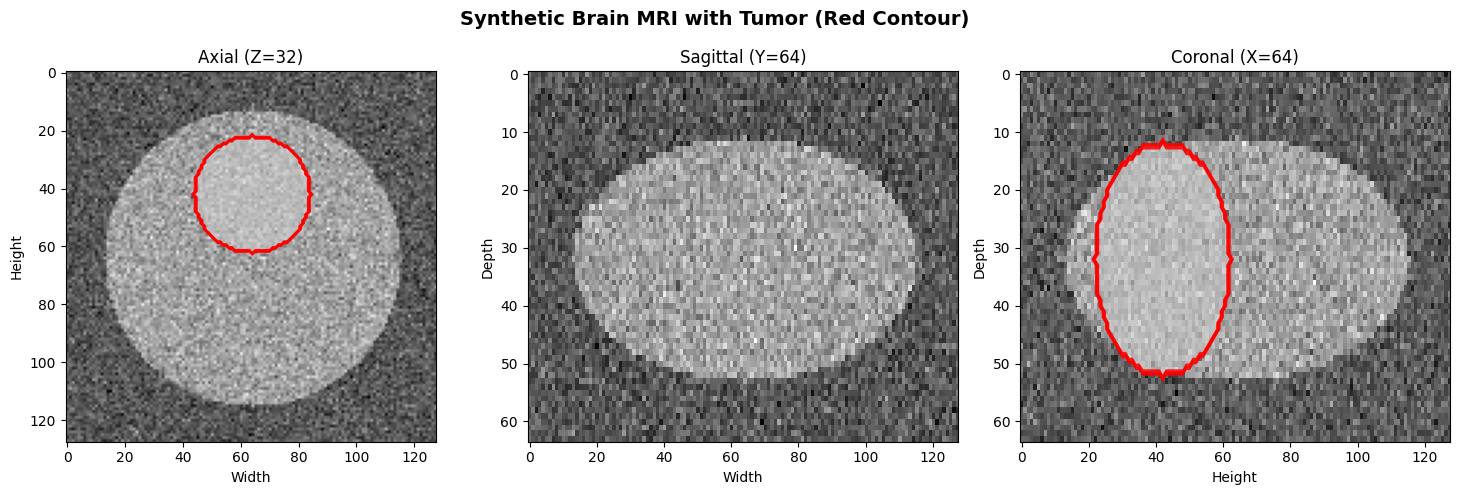

In [4]:
def plot_volume_slices(volume, mask=None, slice_indices=None, title="3D Volume Visualization"):
    """
    Plot orthogonal slices (axial, sagittal, coronal) of a 3D volume.
    
    Args:
        volume: 3D numpy array (D, H, W)
        mask: Optional binary mask to overlay
        slice_indices: Tuple of (d, h, w) slice positions, defaults to center
        title: Plot title
    """
    D, H, W = volume.shape
    
    if slice_indices is None:
        slice_indices = (D//2, H//2, W//2)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Axial slice (along Z/depth axis)
    axes[0].imshow(volume[slice_indices[0]], cmap='gray')
    if mask is not None:
        axes[0].contour(mask[slice_indices[0]], colors='red', linewidths=1, alpha=0.8)
    axes[0].set_title(f'Axial (Z={slice_indices[0]})')
    axes[0].set_xlabel('Width')
    axes[0].set_ylabel('Height')
    
    # Sagittal slice (along Y/height axis)
    axes[1].imshow(volume[:, slice_indices[1], :], cmap='gray', aspect='auto')
    if mask is not None:
        axes[1].contour(mask[:, slice_indices[1], :], colors='red', linewidths=1, alpha=0.8)
    axes[1].set_title(f'Sagittal (Y={slice_indices[1]})')
    axes[1].set_xlabel('Width')
    axes[1].set_ylabel('Depth')
    
    # Coronal slice (along X/width axis)
    axes[2].imshow(volume[:, :, slice_indices[2]], cmap='gray', aspect='auto')
    if mask is not None:
        axes[2].contour(mask[:, :, slice_indices[2]], colors='red', linewidths=1, alpha=0.8)
    axes[2].set_title(f'Coronal (X={slice_indices[2]})')
    axes[2].set_xlabel('Height')
    axes[2].set_ylabel('Depth')
    
    plt.tight_layout()
    plt.show()

# Visualize the synthetic volume with tumor mask
plot_volume_slices(volume, ground_truth, title="Synthetic Brain MRI with Tumor (Red Contour)")

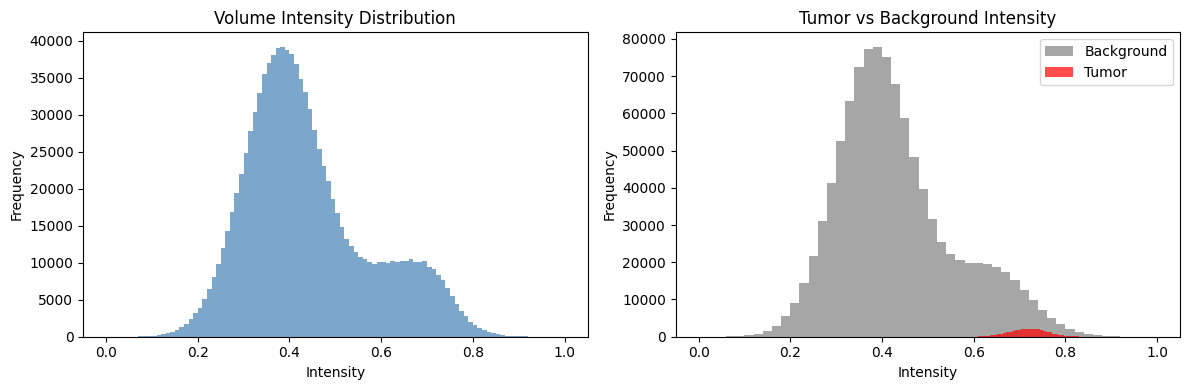

In [5]:
# Intensity histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full volume histogram
axes[0].hist(volume.flatten(), bins=100, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Volume Intensity Distribution')

# Compare tumor vs non-tumor
axes[1].hist(volume[ground_truth == 0].flatten(), bins=50, alpha=0.7, label='Background', color='gray')
axes[1].hist(volume[ground_truth == 1].flatten(), bins=50, alpha=0.7, label='Tumor', color='red')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Tumor vs Background Intensity')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Model Architecture

The Attention U-Net extends the standard U-Net with attention gates that learn to focus on relevant features.

In [6]:
# Create the model
model = AttentionUNet3D(
    in_channels=1,      # Single channel (grayscale/FLAIR)
    out_channels=1,     # Binary segmentation
    base_features=64,   # 64 features in first encoder level
)

# Get parameter counts
params = model.count_parameters()

print("="*60)
print("ATTENTION U-NET 3D ARCHITECTURE")
print("="*60)
print(f"\nParameter Breakdown:")
print(f"  Encoder:    {params['encoder']:>12,} parameters")
print(f"  Decoder:    {params['decoder']:>12,} parameters")
print(f"  Attention:  {params['attention']:>12,} parameters")
print(f"  Output:     {params['output']:>12,} parameters")
print(f"  " + "-"*40)
print(f"  TOTAL:      {params['total']:>12,} parameters")
print(f"\n  ({params['total']/1e6:.2f} million parameters)")

ATTENTION U-NET 3D ARCHITECTURE

Parameter Breakdown:
  Encoder:      56,522,176 parameters
  Decoder:      33,776,320 parameters
  Attention:       524,644 parameters
  Output:               65 parameters
  ----------------------------------------
  TOTAL:        90,823,205 parameters

  (90.82 million parameters)


In [7]:
# Try to use torchinfo for detailed architecture view
try:
    from torchinfo import summary
    print("\nDetailed Architecture (torchinfo):")
    print("="*60)
    summary(model, input_size=(1, 1, 32, 64, 64), depth=3, col_names=["input_size", "output_size", "num_params"])
except ImportError:
    print("\nInstall torchinfo for detailed architecture: pip install torchinfo")
    print("\nModel structure:")
    print(model)


Install torchinfo for detailed architecture: pip install torchinfo

Model structure:
AttentionUNet3D(
  (encoder1): ConvBlock3D(
    (conv1): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (encoder2): DownBlock(
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv_block): ConvBlock3D(
      (conv1): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2

### Attention Gate Explanation

The attention gate is the key component for interpretability:

**Mathematical Formulation:**

Given skip connection **x** (from encoder) and gating signal **g** (from decoder):

1. **Align dimensions**: θₓ = Wₓ·x, φg = Wg·g
2. **Combine**: f = ReLU(θₓ + φg)
3. **Attention coefficients**: ψ = σ(Wψ·f) ∈ [0,1]
4. **Output**: x' = x · ψ

The attention coefficients ψ can be visualized as heatmaps showing where the model focuses.

In [8]:
# Demonstrate attention gate
attn_gate = AttentionGate(skip_channels=64, gate_channels=128)

# Synthetic inputs
skip = torch.randn(1, 64, 32, 64, 64)  # From encoder
gate = torch.randn(1, 128, 16, 32, 32)  # From decoder

# Forward pass
attended_features, attention_map = attn_gate(skip, gate)

print(f"Skip connection shape: {skip.shape}")
print(f"Gating signal shape: {gate.shape}")
print(f"Attention map shape: {attention_map.shape}")
print(f"Attention range: [{attention_map.min():.3f}, {attention_map.max():.3f}]")

Skip connection shape: torch.Size([1, 64, 32, 64, 64])
Gating signal shape: torch.Size([1, 128, 16, 32, 32])
Attention map shape: torch.Size([1, 1, 32, 64, 64])
Attention range: [0.285, 0.858]


## 4. Inference Demo

Running the model on our synthetic data and visualizing attention maps.

In [9]:
# Prepare input tensor
input_tensor = torch.from_numpy(volume).unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
target_tensor = torch.from_numpy(ground_truth).unsqueeze(0).unsqueeze(0)

print(f"Input shape: {input_tensor.shape}")
print(f"Target shape: {target_tensor.shape}")

# Run inference
model.eval()
with torch.no_grad():
    output, attention_maps = model(input_tensor, return_attention=True)

print(f"Output shape: {output.shape}")
print(f"Number of attention maps: {len(attention_maps)}")

Input shape: torch.Size([1, 1, 64, 128, 128])
Target shape: torch.Size([1, 1, 64, 128, 128])
Output shape: torch.Size([1, 1, 64, 128, 128])
Number of attention maps: 4


In [10]:
# Convert output to probability and binary mask
probabilities = torch.sigmoid(output)
predicted_mask = (probabilities > 0.5).float()

# Convert to numpy for visualization
pred_np = predicted_mask.squeeze().numpy()
prob_np = probabilities.squeeze().numpy()

print(f"Prediction stats:")
print(f"  Probability range: [{prob_np.min():.3f}, {prob_np.max():.3f}]")
print(f"  Predicted tumor voxels: {pred_np.sum():.0f}")
print(f"  Ground truth tumor voxels: {ground_truth.sum():.0f}")

Prediction stats:
  Probability range: [0.525, 0.527]
  Predicted tumor voxels: 1048576
  Ground truth tumor voxels: 33401


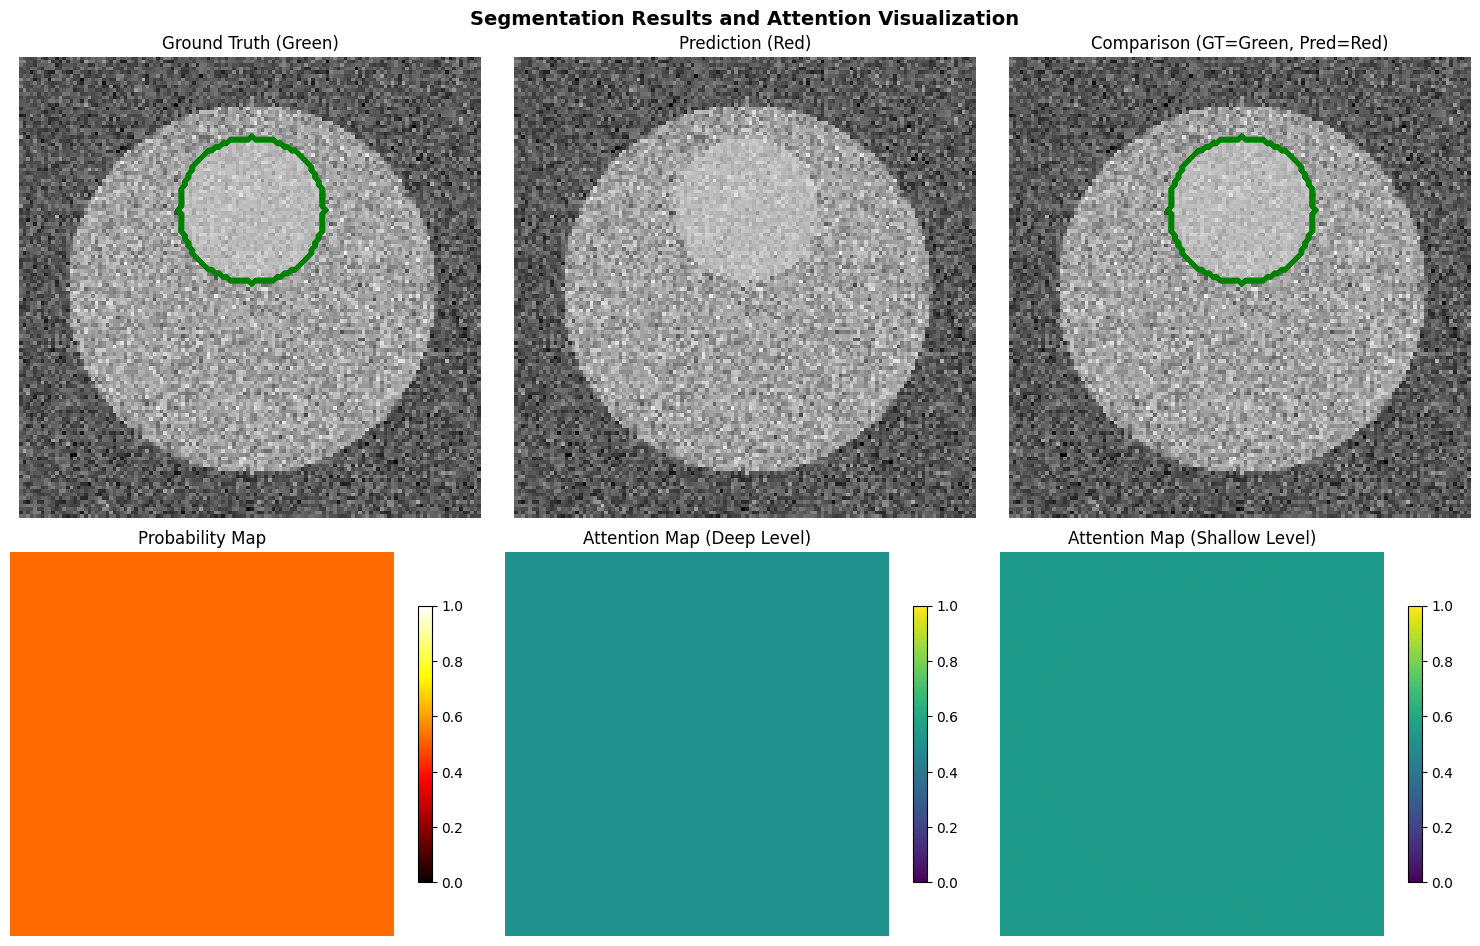

In [11]:
# Visualize prediction vs ground truth
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
slice_idx = volume.shape[0] // 2

# Top row: Volume with ground truth
axes[0, 0].imshow(volume[slice_idx], cmap='gray')
axes[0, 0].contour(ground_truth[slice_idx], colors='green', linewidths=2)
axes[0, 0].set_title('Ground Truth (Green)')

# Top middle: Volume with prediction
axes[0, 1].imshow(volume[slice_idx], cmap='gray')
axes[0, 1].contour(pred_np[slice_idx], colors='red', linewidths=2)
axes[0, 1].set_title('Prediction (Red)')

# Top right: Overlay comparison
axes[0, 2].imshow(volume[slice_idx], cmap='gray')
axes[0, 2].contour(ground_truth[slice_idx], colors='green', linewidths=2, linestyles='solid')
axes[0, 2].contour(pred_np[slice_idx], colors='red', linewidths=2, linestyles='dashed')
axes[0, 2].set_title('Comparison (GT=Green, Pred=Red)')

# Bottom row: Probability map and attention
axes[1, 0].imshow(prob_np[slice_idx], cmap='hot', vmin=0, vmax=1)
axes[1, 0].set_title('Probability Map')
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], shrink=0.6)

# Attention maps (upsample the deepest one)
attn_deep = attention_maps[0].squeeze().numpy()  # Deepest level
attn_mid = slice(attn_deep.shape[0] // 2, attn_deep.shape[0] // 2 + 1)
axes[1, 1].imshow(attn_deep[attn_deep.shape[0]//2], cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title('Attention Map (Deep Level)')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], shrink=0.6)

# Shallow attention
attn_shallow = attention_maps[-1].squeeze().numpy()
axes[1, 2].imshow(attn_shallow[slice_idx], cmap='viridis', vmin=0, vmax=1)
axes[1, 2].set_title('Attention Map (Shallow Level)')
plt.colorbar(axes[1, 2].images[0], ax=axes[1, 2], shrink=0.6)

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Segmentation Results and Attention Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Performance Metrics

Computing Dice score and other segmentation metrics.

In [12]:
# Calculate Dice score
dice = dice_coefficient(probabilities, target_tensor)

print("="*50)
print("SEGMENTATION METRICS")
print("="*50)
print(f"\nDice Coefficient: {dice.item():.4f}")

# IoU calculation
pred_binary = (probabilities > 0.5).float()
intersection = (pred_binary * target_tensor).sum()
union = pred_binary.sum() + target_tensor.sum() - intersection
iou = (intersection + 1e-6) / (union + 1e-6)
print(f"IoU (Jaccard): {iou.item():.4f}")

# Precision & Recall
tp = (pred_binary * target_tensor).sum()
fp = (pred_binary * (1 - target_tensor)).sum()
fn = ((1 - pred_binary) * target_tensor).sum()

precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

print(f"Precision: {precision.item():.4f}")
print(f"Recall: {recall.item():.4f}")

SEGMENTATION METRICS

Dice Coefficient: 0.0617
IoU (Jaccard): 0.0319
Precision: 0.0319
Recall: 1.0000


In [13]:
# Test loss functions
dice_loss = DiceLoss()
combined_loss = CombinedLoss()

d_loss = dice_loss(output, target_tensor)
c_loss = combined_loss(output, target_tensor)

print(f"\nLoss Values:")
print(f"  Dice Loss: {d_loss.item():.4f}")
print(f"  Combined Loss: {c_loss.item():.4f}")
print(f"  Components: {combined_loss.get_component_losses()}")


Loss Values:
  Dice Loss: 0.9399
  Combined Loss: 0.8414
  Components: {'dice': 0.9399319887161255, 'bce': 0.7429203987121582}


## 6. Summary

This notebook demonstrated:

1. **Data Visualization**: 3D volume slicing and intensity analysis
2. **Model Architecture**: Attention U-Net with ~90M parameters
3. **Attention Mechanism**: Visualizable attention coefficients for interpretability
4. **Inference Pipeline**: Running predictions on volumetric data
5. **Metrics**: Dice, IoU, Precision, Recall

### Next Steps
- Train on real BraTS dataset
- Implement federated learning with Flower
- Build FastAPI inference service
- Create Three.js visualization frontend